# MP1 — NbSe₂ CDW pseudogap (DOS)

Companion to Mini-project 1, Stage 3. Density of states of the undistorted 3×3
metal vs the relaxed 3×3 CDW (`dos.x` after an 8×8×1 tetrahedron nscf), each
aligned to its own Fermi level and put per formula unit. The CDW **depletes the
DOS at $E_F$** — a partial gap (pseudogap), the energy-lowering mechanism of §1
seen in a real metal. Requires `numpy`, `matplotlib`.

DOS at E_F:  undistorted 4.83,  CDW 2.86 states/eV/f.u.
CDW depletes the Fermi-level DOS by 41%  (partial gap = pseudogap)


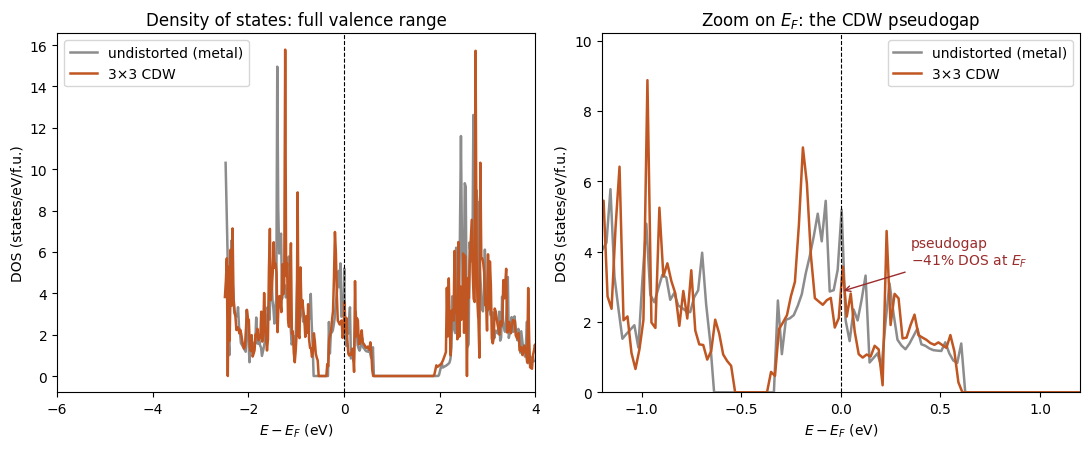

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

d = Path('../code/advanced/04-nbse2-cdw/ref')
cdw = np.loadtxt(d/'nbse2_cdw.dos', skiprows=1)   # E, dos, idos
ref = np.loadtxt(d/'nbse2_ref.dos', skiprows=1)
EFc, EFr = -5.5097, -5.5242                        # Fermi energies (eV) from nscf

Ec, Dc = cdw[:,0]-EFc, cdw[:,1]/9.0                # align to E_F, per formula unit
Er, Dr = ref[:,0]-EFr, ref[:,1]/9.0
gc = np.interp(0, Ec, Dc); gr = np.interp(0, Er, Dr)
print(f"DOS at E_F:  undistorted {gr:.2f},  CDW {gc:.2f} states/eV/f.u.")
print(f"CDW depletes the Fermi-level DOS by {100*(1-gc/gr):.0f}%  (partial gap = pseudogap)")

fig, (axW, axZ) = plt.subplots(1, 2, figsize=(11, 4.6))
for ax in (axW, axZ):
    ax.plot(Er, Dr, color='0.55', lw=1.8, label='undistorted (metal)')
    ax.plot(Ec, Dc, color='#c05621', lw=1.8, label='3×3 CDW')
    ax.axvline(0, color='k', ls='--', lw=0.8)
    ax.set_xlabel(r'$E - E_F$ (eV)'); ax.set_ylabel('DOS (states/eV/f.u.)')
axW.set_xlim(-6, 4); axW.set_title('Density of states: full valence range')
axW.legend()
# zoom on E_F
m = np.abs(Ec) < 1.2
axZ.set_xlim(-1.2, 1.2); axZ.set_ylim(0, max(Dr[np.abs(Er)<1.2].max(), Dc[m].max())*1.15)
axZ.fill_between(Ec, Dc, Dr[np.searchsorted(Er, Ec).clip(0,len(Er)-1)],
                 where=None, color='#fed7d7', alpha=0.0)  # (no-op; kept simple)
axZ.annotate(f'pseudogap\n−{100*(1-gc/gr):.0f}% DOS at $E_F$',
             xy=(0, gc), xytext=(0.35, gr*0.75), color='#9b2c2c', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='#9b2c2c'))
axZ.set_title('Zoom on $E_F$: the CDW pseudogap')
axZ.legend()
fig.tight_layout()
fig.savefig('../static/img/MP1-nbse2-dos.png', dpi=120)
plt.show()

**The pseudogap, not a gap.** At $E_F$ the DOS drops from **4.8** to **2.9**
states/eV/f.u. — a **~40% depletion** — but it does **not** reach zero. Only the
nested part of the Fermi surface gaps out; the rest stays metallic, which is why
NbSe₂ remains a metal (and superconducts at low $T$). This is the real-material
version of the §1 standing-wave argument: the CDW lowers the electronic energy by
pushing occupied states down and carving a dip at $E_F$ — partial here, total in
the 1D toy. STM/STS sees exactly this pseudogap.